### This notebook explores whether shape extraction can recover shapes from perfect OLS coefficients of noise-free trajectories. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pathlib import Path
import sys

project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

from scripts.shape_uncertainty.simulated_data.data_generator import make_data_splits
from scripts.shape_uncertainty.analysis.plot_helpers import plot_individual_diagnostic, plot_sweep
from scripts.shape_uncertainty.model.model_evaluation import ExtractionEvaluator


#### Step 1: Generate a dataset

In [ ]:
# Specify the configuration for the data generation 
simulation_config = dict(D=2000, 
                         N=20, 
                         hyperparams=None, # g0 etc
                         sigma=0.008, # Variance for the observation noise
                         ranges=None, # covariate ranges
                         T=1.0, 
                         regular=False, 
                         include_endpoints=True,
)

# Create training, validation and test datasets
train, val, test = make_data_splits(simulation_config, seed=42)

print("train/val/test:", train.D, val.D, test.D, "- sigma:", train.gen_config["sigma"])

train/val/test: 2000 2000 2000 - sigma: 0.008


#### Step 2: Inspect the data

In [3]:
# Specify indices for patients in the training data whose curves to inspect
target_patients = [0, 1, 2, 3, 4, 5] 

# Print the covariate vectors for the target patients
covariate_df = pd.DataFrame(train.X)
covariate_table = covariate_df.iloc[target_patients]
print(covariate_table)


       size        age     weight    dosage
0  0.272164  35.888110  98.367758  0.249787
1  0.276340  53.980959  89.488354  0.259352
2  0.344727  34.174232  89.096513  0.490207
3  0.302023  47.761604  55.360469  0.057559
4  0.395300  74.476220  79.030273  0.810210
5  0.211606  55.326094  92.744170  0.475238


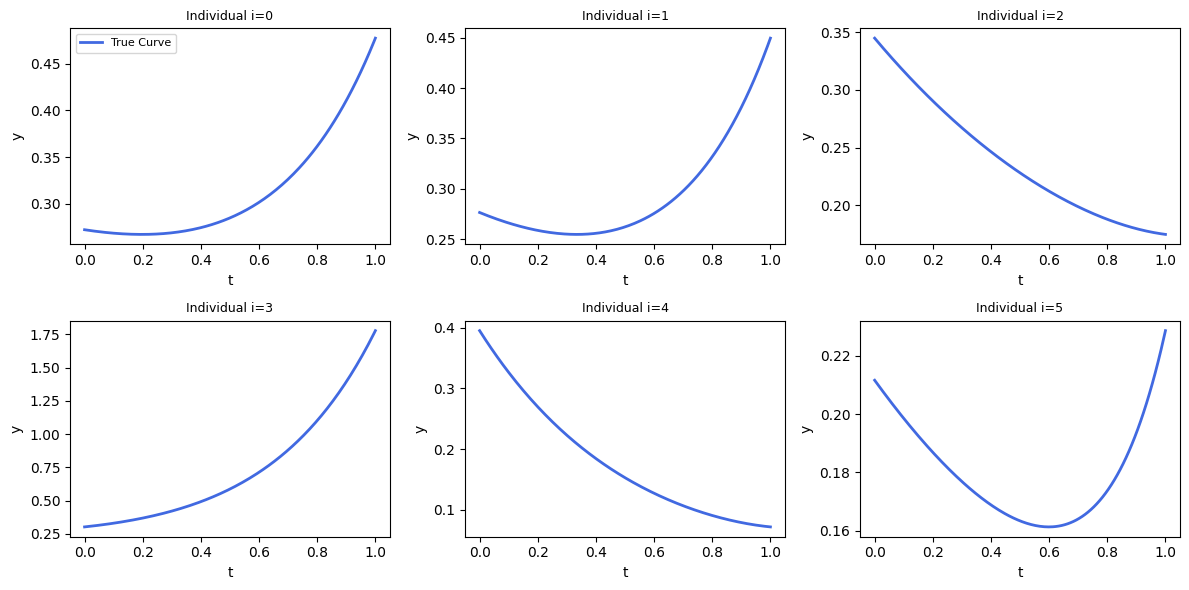

In [4]:
# For the target_patients, we plot the ture trajectories and the noisy observations 
fig = plot_individual_diagnostic(
    dataset=train,
    indices=target_patients,
    inference_engine=None,
    show_true=True,        # 1. Ground-truth trajectory
    show_noisy=False,       # 2. Noisy observed data points
    show_estimated=False,  # 3. We do not have a learned trajectory yet.
)
plt.show()

#### Step 3: Explore quality of shape extraction machinery

We explore whether we can extract the correct shape summary under ideal conditions. There is no NN involved here. 

In [9]:
# 1. Create an evaluator for the training dataset
evaluator = ExtractionEvaluator(train)

# 2. Define some slope and curvature thresholds
upsilon_rel_1=0.0
upsilon_rel_2=0.0

# 3. Get the analytically-derived ground-truth shape summaries
true_shapes = evaluator.get_true_shape_summary(upsilon_rel_1, upsilon_rel_2)


 # 4. Specify some model resoluton at which we want to evaluate the shape extraction
model_res = {"nr_obs": 20, "nr_interior_knots": 5}

# 5. Get OLS-extracted shape summaries 
predicted_shapes = evaluator.shape_summaries_at(
    nr_obs=model_res["nr_obs"],                        # observation count used for fitting
    nr_interior_knots=model_res["nr_interior_knots"],  # B = K + d + 1 = 5 + 4 = 9 
    u1_rel=upsilon_rel_1, 
    u2_rel=upsilon_rel_2
)

# 6. Print table of shape summaries
def _shape_states(summary):
    return [state for state, _ in summary]

df_shapes = pd.DataFrame({
    "patient": target_patients,
    "true_summary": [_shape_states(true_shapes[i]) for i in target_patients],
    "predicted_summary": [_shape_states(predicted_shapes[i]) for i in target_patients],
})
display(df_shapes)

# 7. Print table of transition time points
def _transition_times(summary):
    return [f"{time:.4f}" for _, time in summary]

df_transition_times = pd.DataFrame({
    "patient": target_patients,
    "true_transition_times": [_transition_times(true_shapes[i]) for i in target_patients],
    "predicted_transition_times": [_transition_times(predicted_shapes[i]) for i in target_patients],
})
display(df_transition_times)


,patient,true_summary,predicted_summary
0,0,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]"
1,1,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]"
2,2,[convex_decreasing],[convex_decreasing]
3,3,[convex_increasing],[convex_increasing]
4,4,[convex_decreasing],[convex_decreasing]
5,5,"[convex_decreasing, convex_increasing]","[convex_decreasing, convex_increasing]"


,patient,true_transition_times,predicted_transition_times
0,0,"[0.0000, 0.1969]","[0.0000, 0.1971]"
1,1,"[0.0000, 0.3343]","[0.0000, 0.3344]"
2,2,[0.0000],[0.0000]
3,3,[0.0000],[0.0000]
4,4,[0.0000],[0.0000]
5,5,"[0.0000, 0.5989]","[0.0000, 0.5984]"


#### Step 4: Systematically explore how well the shape extraction works

Under ideal conditions (noise-free data and without the neural network), we explore the effect of varying:

- The number of observations
- The number of knots

,nr_obs,accuracy
0,5,0.0000
1,10,0.9980
2,20,0.9995
3,40,0.9995
4,80,0.9990


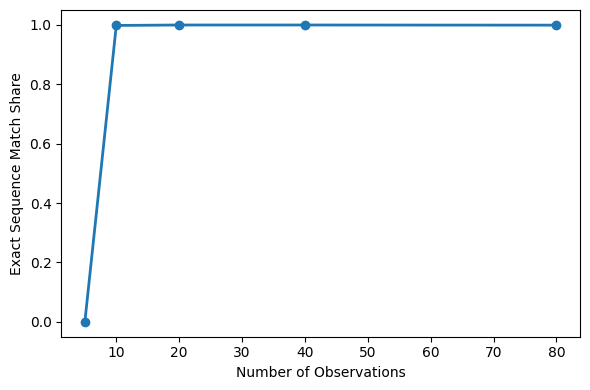

,nr_interior_knots,accuracy
0,1,0.9370
1,3,0.9975
2,5,0.9995
3,7,1.0000
4,9,1.0000


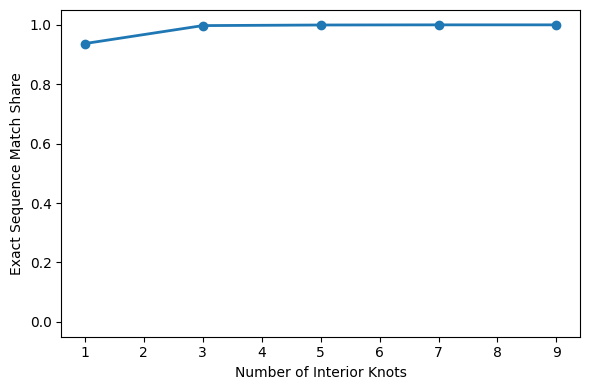

In [10]:
# We keep the slope and curvature thresholds fixed while sweeping observation and knot counts
fixed_u1_rel = upsilon_rel_1
fixed_u2_rel = upsilon_rel_2

# Sweep observation counts with a fixed spline resolution (nr interior knots = 5)
nr_obs_values = [5, 10, 20, 40, 80]
observation_sweep = evaluator.sweep_observations(
    nr_obs_values,
    model_res["nr_interior_knots"],
    fixed_u1_rel,
    fixed_u2_rel,
 )

df_obs_sweep = pd.DataFrame(observation_sweep, columns=["nr_obs", "accuracy"])
display(df_obs_sweep)

fig = plot_sweep(observation_sweep, xlabel="Number of Observations")
plt.show()

# Sweep know counts with a fixed observation count (nr obs = 20)
nr_knot_values = [1, 3, 5, 7, 9]
knot_sweep = evaluator.sweep_knots(
    model_res["nr_obs"],
    nr_knot_values,
    fixed_u1_rel,
    fixed_u2_rel,
 )

df_knot_sweep = pd.DataFrame(knot_sweep, columns=["nr_interior_knots", "accuracy"])
display(df_knot_sweep)


fig = plot_sweep(knot_sweep, xlabel="Number of Interior Knots")
plt.show()

#### Step 5: Explore Mismatch Occurances


In [11]:
# We explore the sources of the mismatches
mismatches = evaluator.find_mismatches(
    nr_obs=model_res["nr_obs"],
    nr_interior_knots=model_res["nr_interior_knots"],
    u1_rel=upsilon_rel_1,
    u2_rel=upsilon_rel_2,
 )

df_mismatches = pd.DataFrame({
    "patient": [m["i"] for m in mismatches],
    "true_summary": [_shape_states(m["true"]) for m in mismatches],
    "predicted_summary": [_shape_states(m["predicted"]) for m in mismatches],
    "true_transition_times": [_transition_times(m["true"]) for m in mismatches],
    "predicted_transition_times": [_transition_times(m["predicted"]) for m in mismatches],
})
display(df_mismatches)

# Finding:

# Case A — minimum near t=0 ([constant, convex_increasing] vs [convex_decreasing, convex_increasing]):
# These mismatches are near-boundary minima sitting just after t=0. 
# Both paths agree the curve is convex-increasing almost throughout, and disagree only on 
# whether the vanishingly short initial descending whisker clears the 1% flatness threshold.
# The analytic reference calls it constant, the spline extractor calls it convex_decreasing.


# Case B — minimum near t=T ([convex_decreasing, constant] vs [convex_decreasing, convex_increasing]):
# These mismatches are near-boundary minima sitting just before t=T.
# Both paths agree the curve is convex-decreasing almost throughout, and disagree only on 
# whether the vanishingly short final ascending whisker clears the 1% flatness threshold. 
# the analytic reference calls it constant, the spline extractor calls it convex_increasing.


# Potential Solution:
# Implement a minimum length for the shape states. 

,patient,true_summary,predicted_summary,true_transition_times,predicted_transition_times
0,876,[convex_increasing],"[concave_increasing, convex_increasing]",[0.0000],"[0.0000, 0.0071]"
